# Part A — Transfer Learning Experiments
Comparing base models vs transfer learning options on CIFAR-10.

In [1]:
import sys
sys.path.append('.')

import copy
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    jaccard_score, confusion_matrix, classification_report
)

from models.ResNet import ResNet, BasicBlock
from models.VGG import VGG
from models.Transfer import Transfer_Config, build_transfer_model
from train import get_loaders, train_one_epoch, validate

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']
print(f'Using device: {DEVICE}')

Using device: cuda


In [2]:
# ── Shared params dict used by get_loaders / get_transforms ──────────────────
BASE_PARAMS = {
    'dataset': 'cifar10', 'data_dir': './data', 'num_workers': 2,
    'mean': (0.4914, 0.4822, 0.4465), 'std': (0.2023, 0.1994, 0.2010),
    'batch_size': 64, 'learning_rate': 1e-3, 'weight_decay': 1e-4,
    'epochs': 20, 'log_interval': 100, 'resize_224': False,
}

train_loader, val_loader = get_loaders(BASE_PARAMS)
print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

100.0%


Train batches: 782  |  Val batches: 157


In [3]:
# ── Training helper ───────────────────────────────────────────────────────────
def train_model(model, params, train_loader, val_loader, save_path):
    """Train model and return history of train/val loss and accuracy."""
    criterion = nn.CrossEntropyLoss()
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable, lr=params['learning_rate'],
                                 weight_decay=params['weight_decay'])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc, best_weights = 0.0, None

    for epoch in range(1, params['epochs'] + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer,
                                          criterion, DEVICE, params['log_interval'])
        val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch}/{params["epochs"]}  '
              f'train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}  '
              f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

        if val_acc > best_acc:
            best_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, save_path)

    model.load_state_dict(best_weights)
    print(f'Best val acc: {best_acc:.4f}')
    return history

In [4]:
# ── Evaluation helper (all metrics) ──────────────────────────────────────────
def evaluate(model, loader):
    """Return dict with loss, accuracy, per-class metrics, IoU, F1, confusion matrix."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    all_preds, all_labels = [], []
    total_loss, n = 0.0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            total_loss += criterion(out, labels).item() * imgs.size(0)
            preds = out.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            n += imgs.size(0)

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)

    cm = confusion_matrix(y_true, y_pred)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    return {
        'loss':          total_loss / n,
        'accuracy':      (y_true == y_pred).mean(),
        'per_class_acc': per_class_acc,
        'f1_macro':      f1_score(y_true, y_pred, average='macro'),
        'f1_per_class':  f1_score(y_true, y_pred, average=None),
        'precision':     precision_score(y_true, y_pred, average=None),
        'recall':        recall_score(y_true, y_pred, average=None),
        'iou_per_class': jaccard_score(y_true, y_pred, average=None),
        'mean_iou':      jaccard_score(y_true, y_pred, average='macro'),
        'confusion_matrix': cm,
    }

## Experiment 1 — Base ResNet-18 (from scratch)

In [5]:
resnet_base = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10).to(DEVICE)
params_base = {**BASE_PARAMS, 'epochs': 30}
hist_resnet = train_model(resnet_base, params_base, train_loader, val_loader,
                          save_path='best_resnet_base.pth')
metrics_resnet = evaluate(resnet_base, val_loader)

  [100/782] loss: 1.9395  acc: 0.2894
  [200/782] loss: 1.8065  acc: 0.3336
  [300/782] loss: 1.7312  acc: 0.3621
  [400/782] loss: 1.6677  acc: 0.3864
  [500/782] loss: 1.6031  acc: 0.4096
  [600/782] loss: 1.5461  acc: 0.4313
  [700/782] loss: 1.4934  acc: 0.4521
Epoch 1/30  train_loss=1.4553 train_acc=0.4669  val_loss=1.1775 val_acc=0.5778
  [100/782] loss: 1.0681  acc: 0.6192
  [200/782] loss: 1.0453  acc: 0.6284
  [300/782] loss: 1.0340  acc: 0.6310
  [400/782] loss: 1.0110  acc: 0.6396
  [500/782] loss: 0.9988  acc: 0.6439
  [600/782] loss: 0.9841  acc: 0.6490
  [700/782] loss: 0.9735  acc: 0.6528
Epoch 2/30  train_loss=0.9606 train_acc=0.6578  val_loss=0.8749 val_acc=0.6955
  [100/782] loss: 0.8557  acc: 0.6981
  [200/782] loss: 0.8306  acc: 0.7064
  [300/782] loss: 0.8126  acc: 0.7141
  [400/782] loss: 0.8013  acc: 0.7208
  [500/782] loss: 0.7926  acc: 0.7228
  [600/782] loss: 0.7864  acc: 0.7249
  [700/782] loss: 0.7781  acc: 0.7274
Epoch 3/30  train_loss=0.7718 train_acc=0.72

## Experiment 2 — Base VGG-16 (from scratch)

In [6]:
vgg_base = VGG(dept='16', num_class=10).to(DEVICE)
params_vgg = {**BASE_PARAMS, 'epochs': 20}
hist_vgg = train_model(vgg_base, params_vgg, train_loader, val_loader,
                       save_path='best_vgg_base.pth')
metrics_vgg = evaluate(vgg_base, val_loader)

  [100/782] loss: 2.2531  acc: 0.1486
  [200/782] loss: 2.1359  acc: 0.1651
  [300/782] loss: 2.0732  acc: 0.1756
  [400/782] loss: 2.0379  acc: 0.1839
  [500/782] loss: 2.0171  acc: 0.1898
  [600/782] loss: 2.0002  acc: 0.1955
  [700/782] loss: 1.9765  acc: 0.2029
Epoch 1/20  train_loss=1.9616 train_acc=0.2084  val_loss=2.0347 val_acc=0.2244
  [100/782] loss: 1.7951  acc: 0.2706
  [200/782] loss: 1.7776  acc: 0.2736
  [300/782] loss: 1.7461  acc: 0.2887
  [400/782] loss: 1.7341  acc: 0.2968
  [500/782] loss: 1.7210  acc: 0.3047
  [600/782] loss: 1.7107  acc: 0.3095
  [700/782] loss: 1.6989  acc: 0.3151
Epoch 2/20  train_loss=1.6888 train_acc=0.3192  val_loss=1.6616 val_acc=0.3079
  [100/782] loss: 1.5806  acc: 0.3667
  [200/782] loss: 1.5810  acc: 0.3700
  [300/782] loss: 1.5813  acc: 0.3720
  [400/782] loss: 1.5739  acc: 0.3719
  [500/782] loss: 1.5696  acc: 0.3748
  [600/782] loss: 1.5575  acc: 0.3800
  [700/782] loss: 1.5466  acc: 0.3827
Epoch 3/20  train_loss=1.5394 train_acc=0.38

## Experiment 3 — Transfer ResNet-18 Option 1 (resize 224, freeze backbone)

In [7]:
params_opt1 = {**BASE_PARAMS, 'resize_224': True, 'epochs': 10}
train_loader_224, val_loader_224 = get_loaders(params_opt1)

cfg1 = Transfer_Config(backbone='resnet18', num_classes=10, option=1)
model_opt1 = build_transfer_model(cfg1).to(DEVICE)
hist_opt1 = train_model(model_opt1, params_opt1, train_loader_224, val_loader_224,
                        save_path='best_transfer_opt1.pth')
metrics_opt1 = evaluate(model_opt1, val_loader_224)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/rodor/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


  [100/782] loss: 1.2057  acc: 0.6420
  [200/782] loss: 0.9141  acc: 0.7259
  [300/782] loss: 0.7882  acc: 0.7609
  [400/782] loss: 0.7141  acc: 0.7802
  [500/782] loss: 0.6636  acc: 0.7939
  [600/782] loss: 0.6228  acc: 0.8044
  [700/782] loss: 0.5950  acc: 0.8117
Epoch 1/10  train_loss=0.5769 train_acc=0.8162  val_loss=0.4254 val_acc=0.8530
  [100/782] loss: 0.3951  acc: 0.8652
  [200/782] loss: 0.3946  acc: 0.8664
  [300/782] loss: 0.3933  acc: 0.8672
  [400/782] loss: 0.3936  acc: 0.8664
  [500/782] loss: 0.3902  acc: 0.8681
  [600/782] loss: 0.3908  acc: 0.8672
  [700/782] loss: 0.3877  acc: 0.8678
Epoch 2/10  train_loss=0.3878 train_acc=0.8677  val_loss=0.3924 val_acc=0.8641
  [100/782] loss: 0.3748  acc: 0.8767
  [200/782] loss: 0.3741  acc: 0.8729
  [300/782] loss: 0.3735  acc: 0.8710
  [400/782] loss: 0.3689  acc: 0.8732
  [500/782] loss: 0.3671  acc: 0.8742
  [600/782] loss: 0.3660  acc: 0.8744
  [700/782] loss: 0.3664  acc: 0.8742
Epoch 3/10  train_loss=0.3653 train_acc=0.87

## Experiment 4 — Transfer ResNet-18 Option 2 (modify early convs, train all)

In [8]:
cfg2 = Transfer_Config(backbone='resnet18', num_classes=10, option=2)
model_opt2 = build_transfer_model(cfg2).to(DEVICE)
params_opt2 = {**BASE_PARAMS, 'epochs': 30}
hist_opt2 = train_model(model_opt2, params_opt2, train_loader, val_loader,
                        save_path='best_transfer_opt2.pth')
metrics_opt2 = evaluate(model_opt2, val_loader)

  [100/782] loss: 1.4652  acc: 0.4831
  [200/782] loss: 1.2610  acc: 0.5602
  [300/782] loss: 1.1382  acc: 0.6021
  [400/782] loss: 1.0537  acc: 0.6333
  [500/782] loss: 0.9935  acc: 0.6537
  [600/782] loss: 0.9494  acc: 0.6696
  [700/782] loss: 0.9104  acc: 0.6837
Epoch 1/30  train_loss=0.8842 train_acc=0.6923  val_loss=0.6797 val_acc=0.7702
  [100/782] loss: 0.6127  acc: 0.7966
  [200/782] loss: 0.6047  acc: 0.7931
  [300/782] loss: 0.5981  acc: 0.7938
  [400/782] loss: 0.5931  acc: 0.7968
  [500/782] loss: 0.5862  acc: 0.8003
  [600/782] loss: 0.5842  acc: 0.8018
  [700/782] loss: 0.5774  acc: 0.8046
Epoch 2/30  train_loss=0.5722 train_acc=0.8057  val_loss=0.5387 val_acc=0.8184
  [100/782] loss: 0.4835  acc: 0.8378
  [200/782] loss: 0.4870  acc: 0.8377
  [300/782] loss: 0.4911  acc: 0.8370
  [400/782] loss: 0.4933  acc: 0.8354
  [500/782] loss: 0.4915  acc: 0.8351
  [600/782] loss: 0.4892  acc: 0.8359
  [700/782] loss: 0.4866  acc: 0.8367
Epoch 3/30  train_loss=0.4852 train_acc=0.83

## Results — Comparison Table

In [9]:
import pandas as pd

results = {
    'Base ResNet-18':      metrics_resnet,
    'Base VGG-16':         metrics_vgg,
    'Transfer Opt1 (224)': metrics_opt1,
    'Transfer Opt2 (32)':  metrics_opt2,
}

summary = pd.DataFrame([
    {
        'Model':    name,
        'Loss':     f"{m['loss']:.4f}",
        'Accuracy': f"{m['accuracy']*100:.2f}%",
        'F1 Macro': f"{m['f1_macro']:.4f}",
        'Mean IoU': f"{m['mean_iou']:.4f}",
    }
    for name, m in results.items()
])
summary

,Model,Loss,Accuracy,F1 Macro,Mean IoU
0,Base ResNet-18,0.3455,92.44%,0.9245,0.8618
1,Base VGG-16,0.3895,87.66%,0.8756,0.7838
2,Transfer Opt1 (224),0.3709,87.44%,0.8745,0.7804
3,Transfer Opt2 (32),0.2619,94.15%,0.9414,0.8909


## Per-Class Metrics

In [10]:
for name, m in results.items():
    df = pd.DataFrame({
        'Class':    CLASSES,
        'Accuracy': m['per_class_acc'].round(4),
        'F1':       m['f1_per_class'].round(4),
        'Precision':m['precision'].round(4),
        'Recall':   m['recall'].round(4),
        'IoU':      m['iou_per_class'].round(4),
    })
    print(f'\n── {name} ──')
    print(df.to_string(index=False))


── Base ResNet-18 ──
     Class  Accuracy     F1  Precision  Recall    IoU
  airplane     0.945 0.9366     0.9283   0.945 0.8807
automobile     0.970 0.9657     0.9613   0.970 0.9336
      bird     0.879 0.9002     0.9224   0.879 0.8184
       cat     0.845 0.8446     0.8442   0.845 0.7310
      deer     0.925 0.9232     0.9213   0.925 0.8573
       dog     0.890 0.8713     0.8533   0.890 0.7719
      frog     0.936 0.9421     0.9483   0.936 0.8906
     horse     0.939 0.9485     0.9582   0.939 0.9020
      ship     0.960 0.9581     0.9562   0.960 0.9195
     truck     0.955 0.9545     0.9540   0.955 0.9130

── Base VGG-16 ──
     Class  Accuracy     F1  Precision  Recall    IoU
  airplane     0.914 0.8852     0.8582   0.914 0.7941
automobile     0.942 0.9463     0.9506   0.942 0.8980
      bird     0.808 0.8377     0.8698   0.808 0.7208
       cat     0.700 0.7415     0.7883   0.700 0.5892
      deer     0.902 0.8554     0.8133   0.902 0.7473
       dog     0.793 0.8142     0.8365   

## Training Curves

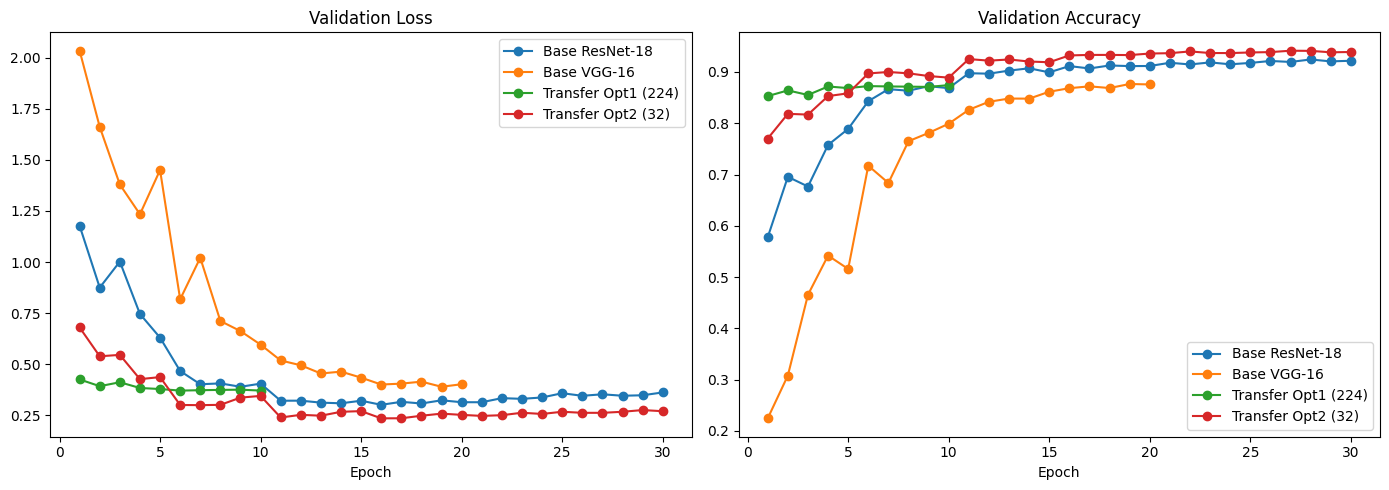

In [11]:
histories = {
    'Base ResNet-18':      hist_resnet,
    'Base VGG-16':         hist_vgg,
    'Transfer Opt1 (224)': hist_opt1,
    'Transfer Opt2 (32)':  hist_opt2,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, h in histories.items():
    epochs = range(1, len(h['val_loss']) + 1)
    axes[0].plot(epochs, h['val_loss'], marker='o', label=name)
    axes[1].plot(epochs, h['val_acc'],  marker='o', label=name)

axes[0].set_title('Validation Loss');  axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('part_a_training_curves.png', dpi=150)
plt.show()

## Confusion Matrices

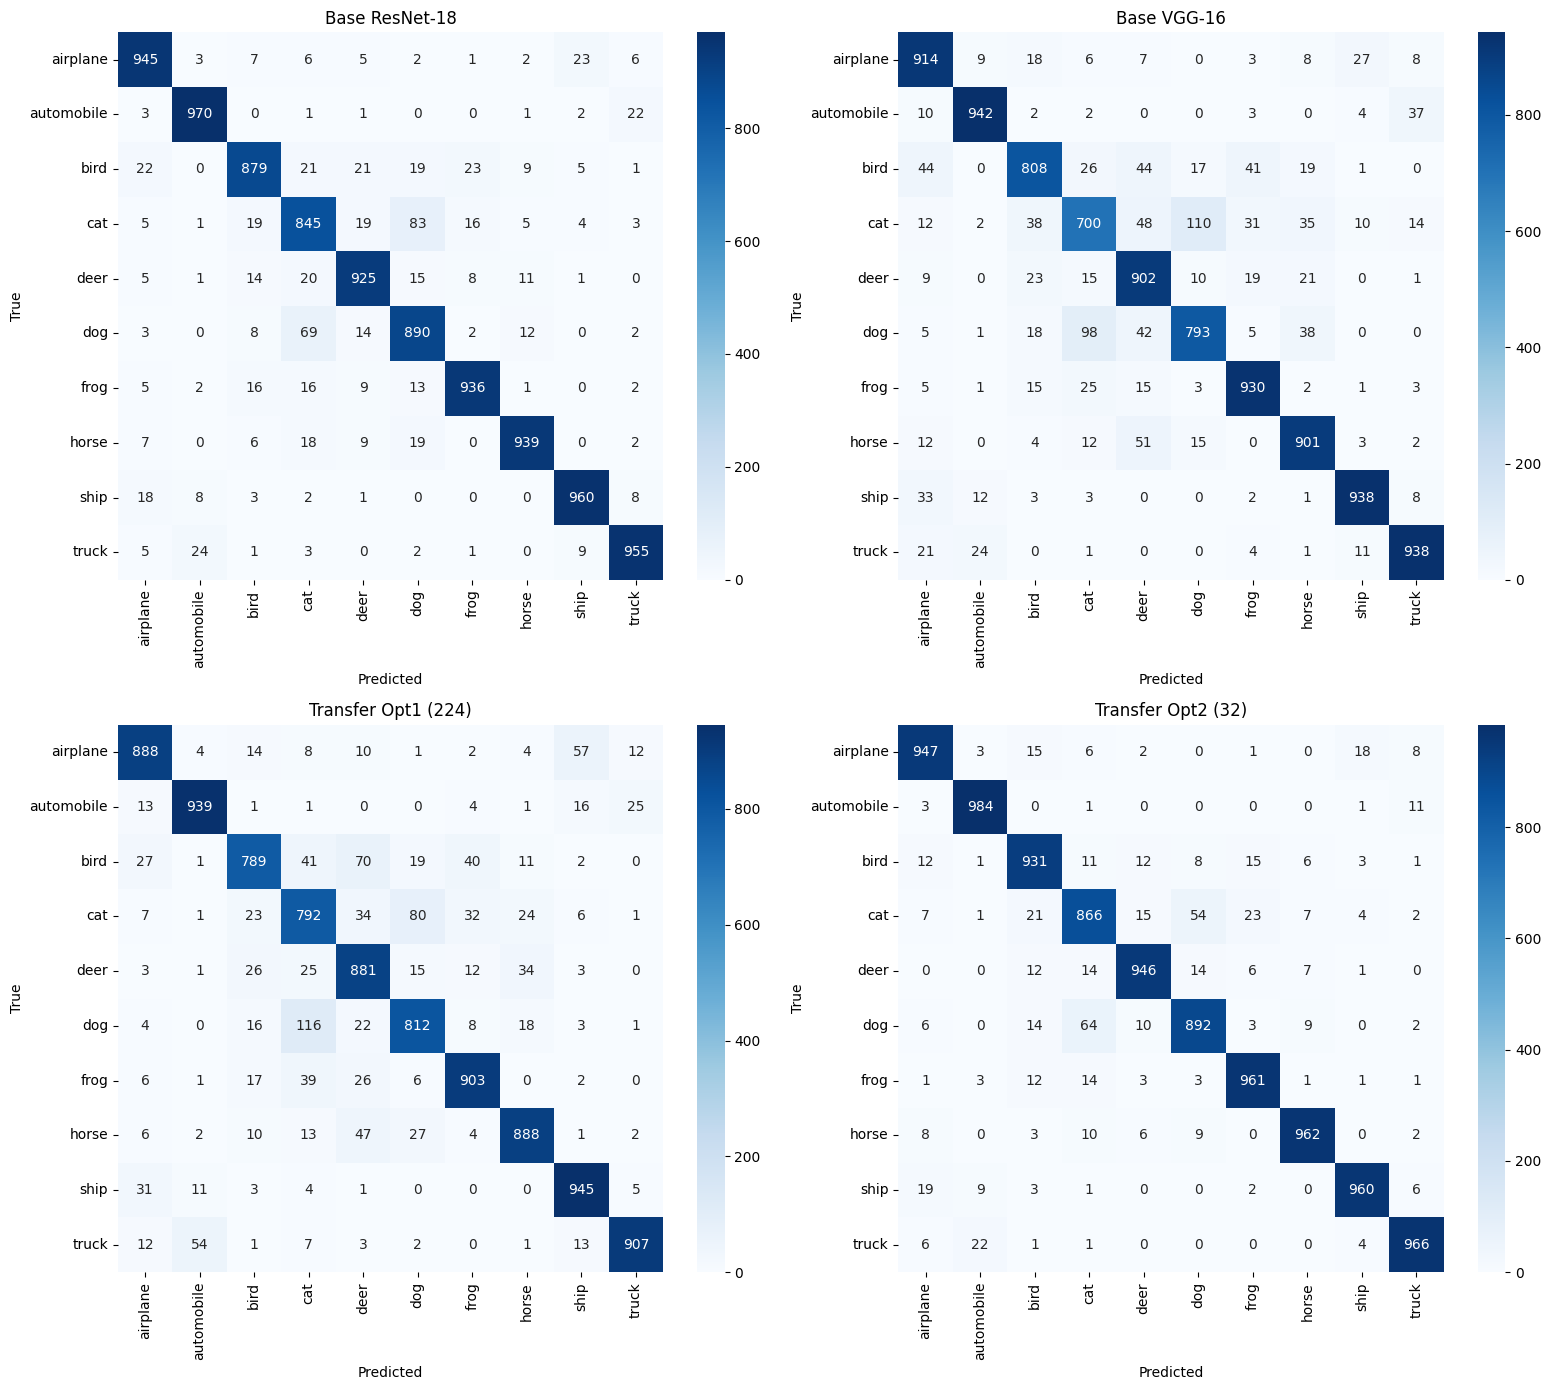

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, (name, m) in zip(axes.flatten(), results.items()):
    sns.heatmap(m['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('part_a_confusion_matrices.png', dpi=150)
plt.show()

## Per-Class IoU Bar Chart

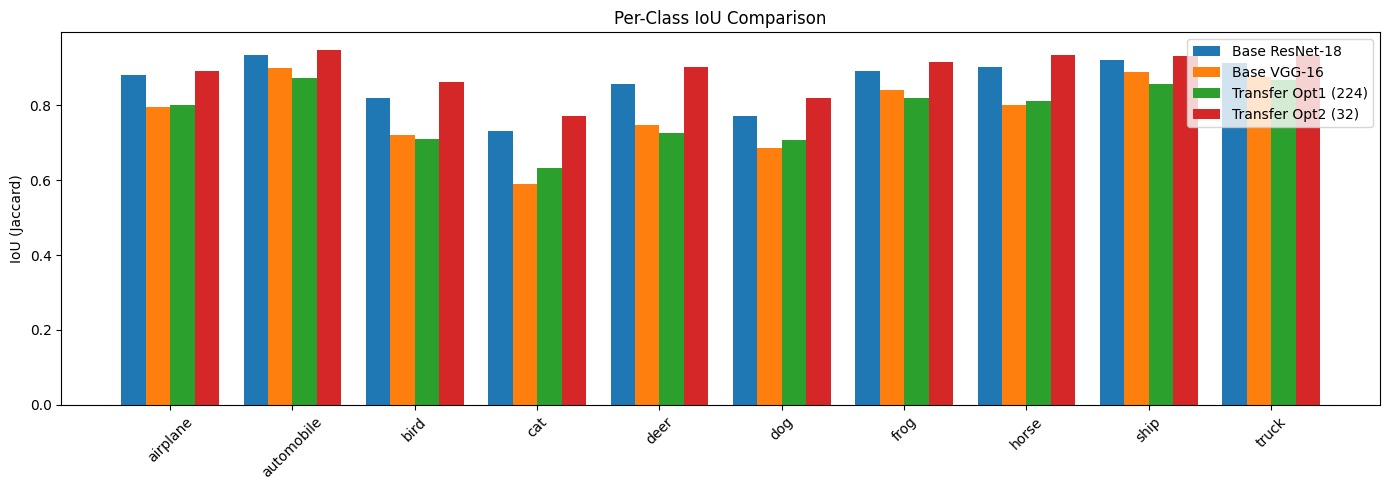

In [13]:
x = np.arange(len(CLASSES))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 5))
for i, (name, m) in enumerate(results.items()):
    ax.bar(x + i * width, m['iou_per_class'], width, label=name)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(CLASSES, rotation=45)
ax.set_ylabel('IoU (Jaccard)')
ax.set_title('Per-Class IoU Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('part_a_iou_per_class.png', dpi=150)
plt.show()